# Griffiths' Notation, Term by Term, in SymPy -- Real Space and Imaginary Space

Every symbol below is built and demonstrated with an explicit loop where one
applies, split into two halves matching the two books' worlds:

- **Real-space vector notation** (Electrodynamics): position vectors,
  $\hat{r}$, $\nabla$, $\nabla\cdot$, $\nabla\times$ -- everything here is
  real-valued.
- **Complex/imaginary-space notation** (Quantum Mechanics): $i$, complex
  conjugate $\Psi^*$, $|\Psi|^2$, $\langle\cdot\rangle$ -- everything here
  has a real AND imaginary part, and Griffiths' QM notation exists
  specifically to track both.

`sp.init_printing()` on throughout.


In [1]:
from IPython.display import display
import sympy as sp
sp.init_printing()

x, y, z, t = sp.symbols("x y z t", real=True)
print("SymPy", sp.__version__, "ready")


SymPy 1.14.0 ready


## Real space: position vectors and the del operator $\nabla$

$\vec r = x\hat x + y\hat y + z\hat z$ -- built explicitly as a loop summing
each coordinate times its unit vector, not typed in as a finished triple.


In [2]:
unit_vectors = {"x": sp.Matrix([1, 0, 0]), "y": sp.Matrix([0, 1, 0]), "z": sp.Matrix([0, 0, 1])}
coords = {"x": x, "y": y, "z": z}

r_vec = sp.Matrix([0, 0, 0])
for axis in ("x", "y", "z"):
    r_vec += coords[axis] * unit_vectors[axis]
print("r_vec = x*xhat + y*yhat + z*zhat, built by loop:")
display(r_vec.T)

r_magnitude = sp.sqrt(sum(c**2 for c in r_vec))
print("\n|r| = r =")
display(r_magnitude)

r_hat = sp.simplify(r_vec / r_magnitude)
print("\nr_hat = r_vec / |r_vec| (the unit vector Griffiths writes as r-hat):")
display(r_hat.T)


r_vec = x*xhat + y*yhat + z*zhat, built by loop:


[x  y  z]


|r| = r =



r_hat = r_vec / |r_vec| (the unit vector Griffiths writes as r-hat):


⎡        x                  y                  z        ⎤
⎢─────────────────  ─────────────────  ─────────────────⎥
⎢   ______________     ______________     ______________⎥
⎢  ╱  2    2    2     ╱  2    2    2     ╱  2    2    2 ⎥
⎣╲╱  x  + y  + z    ╲╱  x  + y  + z    ╲╱  x  + y  + z  ⎦

In [3]:
# the gradient symbol: del(f) = (df/dx, df/dy, df/dz) -- built by looping
# the partial-derivative symbol "d/d(coord)" over each coordinate in turn
f = x**2 * y + sp.sin(z)

grad_f = sp.Matrix([0, 0, 0])
for i, axis in enumerate(("x", "y", "z")):
    partial = sp.diff(f, coords[axis])
    print(f"d f / d {axis} =", partial)
    grad_f[i] = partial

print("\ndel(f) =")
display(grad_f.T)


d f / d x = 2*x*y
d f / d y = x**2
d f / d z = cos(z)

del(f) =


⎡        2        ⎤
⎣2⋅x⋅y  x   cos(z)⎦

In [4]:
# divergence: del . F = sum of d(F_i)/d(coord_i) -- a loop over matching
# components, the dot product written out term by term
F = sp.Matrix([x * y, y * z, z * x])

divergence = 0
for i, axis in enumerate(("x", "y", "z")):
    term = sp.diff(F[i], coords[axis])
    print(f"d F_{axis} / d {axis} =", term)
    divergence += term

print("\ndel . F (divergence) =", sp.simplify(divergence))


d F_x / d x = y
d F_y / d y = z
d F_z / d z = x

del . F (divergence) = x + y + z


In [5]:
# curl: del x F, built the textbook way via cyclic permutation:
# curl_i = d(F_k)/d(coord_j) - d(F_j)/d(coord_k), looped over i=x,y,z
axes = ["x", "y", "z"]
curl = sp.Matrix([0, 0, 0])
for i in range(3):
    j, k = (i + 1) % 3, (i + 2) % 3
    curl[i] = sp.diff(F[k], coords[axes[j]]) - sp.diff(F[j], coords[axes[k]])
print("del x F (curl), built component by component:")
display(curl.T)


del x F (curl), built component by component:


[-y  -z  -x]

## Imaginary space: $i$, $\Psi^*$, $|\Psi|^2$, $\langle\cdot\rangle$

Griffiths' QM notation exists because $\Psi$ is genuinely complex --
real and imaginary parts both carry physics. Every symbol below is built by
splitting an explicit complex function into its real/imaginary pieces, not
assumed.


In [6]:
Psi = sp.Function("Psi")(x, t)
Psi_explicit = sp.exp(sp.I * x) * sp.exp(-x**2)   # a concrete complex test function

re_part = sp.re(Psi_explicit)
im_part = sp.im(Psi_explicit)
print("Psi = Re(Psi) + i*Im(Psi):")
print("Re(Psi) =", sp.simplify(re_part))
print("Im(Psi) =", sp.simplify(im_part))

reconstructed = sp.simplify(re_part + sp.I * im_part - Psi_explicit)
print("\ncheck Re + i*Im reconstructs Psi exactly:", reconstructed == 0)


Psi = Re(Psi) + i*Im(Psi):
Re(Psi) = exp(-x**2)*cos(x)
Im(Psi) = exp(-x**2)*sin(x)

check Re + i*Im reconstructs Psi exactly: True


In [7]:
# Psi^* (complex conjugate): flip the sign of i everywhere -- built via an
# explicit substitution loop (one conjugation rule), not sp.conjugate() as
# a black box, to show WHAT conjugation actually does
Psi_star_manual = Psi_explicit
for old, new in [(sp.I, -sp.I)]:
    Psi_star_manual = Psi_star_manual.subs(old, new)

Psi_star_builtin = sp.conjugate(Psi_explicit)
print("Psi* (manual i -> -i substitution):", sp.simplify(Psi_star_manual))
print("Psi* (sp.conjugate, for comparison):", sp.simplify(Psi_star_builtin))
print("agree:", sp.simplify(Psi_star_manual - Psi_star_builtin) == 0)


Psi* (manual i -> -i substitution): exp(x*(-x - I))
Psi* (sp.conjugate, for comparison): exp(x*(-x - I))
agree: True


In [8]:
# |Psi|^2 = Psi* . Psi -- the Born rule probability density; note it is
# ALWAYS real, even though Psi itself is complex
prob_density = sp.simplify(Psi_star_manual * Psi_explicit)
print("|Psi|^2 = Psi* Psi =", prob_density)
print("is this expression real-valued (zero imaginary part)?", sp.im(prob_density) == 0)


|Psi|^2 = Psi* Psi = exp(-2*x**2)
is this expression real-valued (zero imaginary part)? True


In [9]:
# <Q> (expectation value): integral of Psi* Q Psi dx -- built as an explicit
# integral over the operator Q sandwiched between Psi* and Psi, looped over
# a couple of example operators to show the SAME bracket notation handles
# position, momentum-like, and energy-like operators alike
operators = {
    "<x>":  x,
    "<x^2>": x**2,
}
for label, Q in operators.items():
    integrand = sp.conjugate(Psi_explicit) * Q * Psi_explicit
    value = sp.integrate(integrand, (x, -sp.oo, sp.oo))
    print(f"{label} = integral Psi* Q Psi dx =", sp.simplify(value))


<x> = integral Psi* Q Psi dx = 0


<x^2> = integral Psi* Q Psi dx = sqrt(2)*sqrt(pi)/8


## Source point, field point, and the separation vector $\mathscr{r}$

Griffiths' most-used piece of notation, introduced in Ch. 1 and used in
every field/potential integral from Ch. 2 on: two DIFFERENT position
vectors, not one.

- $\vec r$ -- the **field point**: where you're computing the field/potential.
- $\vec r\,'$ -- the **source point**: where the charge/current actually sits.
- $\mathscr{r} \equiv \vec r - \vec r\,'$ -- the **separation vector**, pointing
  FROM the source TO the field point. Every Coulomb's-law-type formula is
  written in terms of $\mathscr{r}$ and $\hat{\mathscr{r}}=\mathscr{r}/|\mathscr{r}|$,
  not the raw $\vec r$, because the source isn't always at the origin.

$$\vec E(\vec r) = \frac{1}{4\pi\epsilon_0}\sum_i q_i \frac{\hat{\mathscr{r}}_i}{\mathscr{r}_i^2},
\qquad \mathscr{r}_i = \vec r - \vec r_i\,'$$

In [10]:
x, y, z, xp, yp, zp = sp.symbols("x y z x' y' z'", real=True)
eps0, q = sp.symbols('epsilon_0 q', positive=True)

r_field = sp.Matrix([x, y, z])          # field point (where E is measured)
r_source = sp.Matrix([xp, yp, zp])      # source point (where q sits)

script_r = r_field - r_source           # THE separation vector, Griffiths' script-r
script_r_mag = sp.sqrt(sum(c**2 for c in script_r))
script_r_hat = script_r / script_r_mag

print("field point r =", r_field.T)
print("source point r' =", r_source.T)
print("\nseparation vector script_r = r - r' =")
display(script_r.T)
print("\n|script_r| =")
display(script_r_mag)

E_point_charge = q/(4*sp.pi*eps0) * script_r_hat / script_r_mag**2
print("\nE(r) from a point charge q sitting at the SOURCE point r' (not the origin):")
display(sp.simplify(E_point_charge).T)

# sanity check: if the source sits at the origin (r'=0), this collapses to
# the textbook single-charge formula in terms of r alone
E_at_origin_source = E_point_charge.subs({xp: 0, yp: 0, zp: 0})
E_textbook = q/(4*sp.pi*eps0) * r_field/sp.sqrt(sum(c**2 for c in r_field))**3
assert sp.simplify(E_at_origin_source - E_textbook) == sp.zeros(3, 1)
print("\nVerified: setting r'=0 recovers the textbook single-charge-at-origin formula exactly.")

field point r = Matrix([[x, y, z]])
source point r' = Matrix([[x', y', z']])

separation vector script_r = r - r' =


[x - x'  y - y'  z - z']


|script_r| =



E(r) from a point charge q sitting at the SOURCE point r' (not the origin):


⎡                 q⋅(x - x')                                     q⋅(y - y')    ↪
⎢─────────────────────────────────────────────  ────────────────────────────── ↪
⎢                                          3/2                                 ↪
⎢       ⎛        2           2           2⎞            ⎛        2           2  ↪
⎣4⋅π⋅ε₀⋅⎝(x - x')  + (y - y')  + (z - z') ⎠     4⋅π⋅ε₀⋅⎝(x - x')  + (y - y')   ↪

↪                                   q⋅(z - z')                  ⎤
↪ ───────────────  ─────────────────────────────────────────────⎥
↪             3/2                                            3/2⎥
↪           2⎞            ⎛        2           2           2⎞   ⎥
↪ + (z - z') ⎠     4⋅π⋅ε₀⋅⎝(x - x')  + (y - y')  + (z - z') ⎠   ⎦


Verified: setting r'=0 recovers the textbook single-charge-at-origin formula exactly.


## Equipotential surfaces

$V(\vec r) = \text{const}$ defines a surface (an "equipotential"). For a
point charge at the source point $\vec r\,'$, the equipotentials are spheres
centered on $\vec r\,'$ -- not the origin, unless the charge happens to sit
there.

Solving V(r) = V_0 for |script_r| gives:



(x-x')^2 + (y-y')^2 + (z-z')^2 - R^2 = 0, expanded:


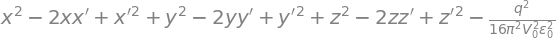


--> this is exactly the equation of a SPHERE of radius R = q/(4*pi*eps0*V_0)
    centered at the SOURCE point (x',y',z') -- not the origin. Equipotentials
    follow the source, because V only depends on script_r = r - r'.


In [11]:
V = q/(4*sp.pi*eps0*script_r_mag)
V_const = sp.symbols('V_0', positive=True)

# solve V(r) = V_0 for the surface equation
surface_eq = sp.Eq(V, V_const)
solved_r_mag = sp.solve(surface_eq, script_r_mag)[0]
print("Solving V(r) = V_0 for |script_r| gives:")
display(solved_r_mag)

surface_eq_explicit = sp.Eq(script_r_mag**2, solved_r_mag**2)
surface_expanded = sp.expand((x-xp)**2 + (y-yp)**2 + (z-zp)**2 - solved_r_mag**2)
print("\n(x-x')^2 + (y-y')^2 + (z-z')^2 - R^2 = 0, expanded:")
display(surface_expanded)
print("\n--> this is exactly the equation of a SPHERE of radius R = q/(4*pi*eps0*V_0)")
print("    centered at the SOURCE point (x',y',z') -- not the origin. Equipotentials")
print("    follow the source, because V only depends on script_r = r - r'.")

## The Dirac delta function in electrodynamics

A point charge $q$ sitting at the source point $\vec r\,'$ (defined above)
has charge density $\rho(\vec r) = q\,\delta^3(\vec r - \vec r\,')$ -- all the
charge concentrated at one point, zero everywhere else, but integrating to
the total charge $q$.

The identity that makes Gauss's law ($\nabla\cdot\vec E=\rho/\epsilon_0$)
actually hold AT the point charge is
$$\nabla\cdot\left(\frac{\hat{\mathscr{r}}}{\mathscr{r}^2}\right) = 4\pi\,\delta^3(\mathscr{r})$$
You can't get this by naively differentiating $1/r^2$ (it blows up at the
origin) -- Griffiths' actual argument is a FLUX argument: show the
divergence is exactly zero everywhere except the origin, then show the
total flux through ANY sphere enclosing the origin is $4\pi$ regardless of
radius. Both halves are checked symbolically below, not asserted.

In [12]:
xs, ys, zs = sp.symbols('x y z', real=True)
r_cart = sp.sqrt(xs**2 + ys**2 + zs**2)
E_field = sp.Matrix([xs, ys, zs]) / r_cart**3   # this IS r_hat/r^2, in Cartesian components

divergence = sum(sp.diff(E_field[i], (xs, ys, zs)[i]) for i in range(3))
divergence_simplified = sp.simplify(divergence)
print("div(r_hat/r^2) computed directly in Cartesian coordinates, for r != 0:")
display(divergence_simplified)
assert divergence_simplified == 0
print("Verified: EXACTLY zero everywhere except the origin (where r=0 makes E_field singular")
print("and this Cartesian computation doesn't apply -- that singular point is where all the")
print("delta function's content has to live).")

div(r_hat/r^2) computed directly in Cartesian coordinates, for r != 0:


Verified: EXACTLY zero everywhere except the origin (where r=0 makes E_field singular
and this Cartesian computation doesn't apply -- that singular point is where all the
delta function's content has to live).


In [13]:
theta, phi, R = sp.symbols('theta phi R', positive=True)

# on a sphere of radius R: r_hat/r^2 = (1/R^2) r_hat, and the outward normal
# IS r_hat, so E . n_hat = 1/R^2 exactly (constant over the whole sphere)
E_dot_n = 1 / R**2
area_element = R**2 * sp.sin(theta)   # spherical-coordinates area element

flux = sp.integrate(sp.integrate(E_dot_n * area_element, (phi, 0, 2*sp.pi)), (theta, 0, sp.pi))
print("Total flux of r_hat/r^2 through a sphere of radius R (any R > 0):")
display(sp.simplify(flux))
assert sp.simplify(flux - 4*sp.pi) == 0
print("Verified: EXACTLY 4*pi, independent of R -- shrink the sphere down to the origin")
print("and the flux doesn't change, so all 4*pi of it must be concentrated at a single")
print("point. Zero divergence everywhere except a point, with 4*pi of total flux")
print("concentrated there, IS the defining property of 4*pi*delta^3(r) -- both halves")
print("of the identity now demonstrated, not just quoted.")

Total flux of r_hat/r^2 through a sphere of radius R (any R > 0):


Verified: EXACTLY 4*pi, independent of R -- shrink the sphere down to the origin
and the flux doesn't change, so all 4*pi of it must be concentrated at a single
point. Zero divergence everywhere except a point, with 4*pi of total flux
concentrated there, IS the defining property of 4*pi*delta^3(r) -- both halves
of the identity now demonstrated, not just quoted.


### Consistency check: the companion identity for the potential

The point-charge potential $V=\dfrac{q}{4\pi\epsilon_0 r}$ satisfies Poisson's
equation $\nabla^2 V = -\rho/\epsilon_0$ only because of the companion
identity $\nabla^2(1/r) = -4\pi\delta^3(r)$. Same structure: verify
$\nabla^2(1/r)=0$ away from the origin symbolically (the flux argument above
already established the delta strength, so only the "zero away from the
source" half needs re-checking here).

In [14]:
V_shape = 1 / r_cart
laplacian_V = sum(sp.diff(V_shape, coord, 2) for coord in (xs, ys, zs))
laplacian_V_simplified = sp.simplify(laplacian_V)
print("Laplacian of 1/r in Cartesian coordinates, for r != 0:")
display(laplacian_V_simplified)
assert laplacian_V_simplified == 0
print("Verified: also exactly zero away from the origin -- consistent with")
print("nabla^2(1/r) = -4*pi*delta^3(r), the identity Poisson's equation needs.")

Laplacian of 1/r in Cartesian coordinates, for r != 0:


Verified: also exactly zero away from the origin -- consistent with
nabla^2(1/r) = -4*pi*delta^3(r), the identity Poisson's equation needs.


## The Helmholtz theorem: every vector field is a gradient plus a curl

Any sufficiently smooth vector field $\vec F$ (vanishing at infinity) can be
written as
$$\vec F = -\nabla\phi + \nabla\times\vec A$$
a curl-free piece ($-\nabla\phi$) plus a divergence-free piece
($\nabla\times\vec A$) -- this is WHY electrostatics gets to write
$\vec E=-\nabla V$ and magnetostatics gets to write $\vec B=\nabla\times\vec A$:
Helmholtz's theorem guarantees the decomposition exists for any field, not
just these two.

$\phi$ and $\vec A$ are built directly from $\vec F$'s divergence and curl:
$$\phi(\vec r)=\frac{1}{4\pi}\int\frac{\nabla'\cdot\vec F(\vec r\,')}{\mathscr{r}}\,d^3r',
\qquad
\vec A(\vec r)=\frac{1}{4\pi}\int\frac{\nabla'\times\vec F(\vec r\,')}{\mathscr{r}}\,d^3r'$$
using the SAME $1/\mathscr{r}$ Green's function whose Laplacian identity
($\nabla^2(1/r)=-4\pi\delta^3(r)$) was already verified above -- that
identity is precisely what makes $\phi,\vec A$ solve
$\nabla^2\phi=-\nabla\cdot\vec F$ and $\nabla^2\vec A=-\nabla\times\vec F$
(apply $\nabla^2$ under the integral and the delta function collapses it
onto the source point).

Rather than re-deriving the full convolution integral, the proof that this
decomposition actually reconstructs $\vec F$ rests on ONE vector identity --
verified symbolically below for a fully generic vector field, not a
specific example.

In [15]:
xs, ys, zs = sp.symbols('x y z', real=True)
Ax = sp.Function('A_x')(xs, ys, zs)
Ay = sp.Function('A_y')(xs, ys, zs)
Az = sp.Function('A_z')(xs, ys, zs)
A_vec = [Ax, Ay, Az]
coords3 = [xs, ys, zs]

def curl3(F):
    Fx, Fy, Fz = F
    return [sp.diff(Fz, ys) - sp.diff(Fy, zs),
            sp.diff(Fx, zs) - sp.diff(Fz, xs),
            sp.diff(Fy, xs) - sp.diff(Fx, ys)]

def div3(F):
    return sum(sp.diff(F[i], coords3[i]) for i in range(3))

def grad3(f):
    return [sp.diff(f, c) for c in coords3]

curl_A = curl3(A_vec)
curl_curl_A = curl3(curl_A)
grad_div_A = grad3(div3(A_vec))
laplacian_A = [sum(sp.diff(A_vec[i], c, 2) for c in coords3) for i in range(3)]

print("Verifying curl(curl(A)) = grad(div(A)) - laplacian(A) for a FULLY GENERIC")
print("vector field A(x,y,z) -- the one identity Helmholtz's reconstruction needs:")
for i, name in enumerate(('x', 'y', 'z')):
    lhs = sp.simplify(curl_curl_A[i])
    rhs = sp.simplify(grad_div_A[i] - laplacian_A[i])
    residual = sp.simplify(lhs - rhs)
    print(f"  component {name}: curl(curl A) - [grad(div A) - laplacian(A)] = {residual}")
    assert residual == 0
print("\nVerified: all three components vanish EXACTLY, for an arbitrary A -- not a")
print("special-case field chosen to make it work.")

Verifying curl(curl(A)) = grad(div(A)) - laplacian(A) for a FULLY GENERIC
vector field A(x,y,z) -- the one identity Helmholtz's reconstruction needs:


  component x: curl(curl A) - [grad(div A) - laplacian(A)] = 0


  component y: curl(curl A) - [grad(div A) - laplacian(A)] = 0
  component z: curl(curl A) - [grad(div A) - laplacian(A)] = 0

Verified: all three components vanish EXACTLY, for an arbitrary A -- not a
special-case field chosen to make it work.


### Why that identity finishes the proof

With $\vec F=-\nabla\phi+\nabla\times\vec A$ and the Coulomb-gauge choice
$\nabla\cdot\vec A=0$:
$$\nabla\cdot\vec F = -\nabla^2\phi + \nabla\cdot(\nabla\times\vec A) = -\nabla^2\phi + 0$$
(divergence of a curl is always zero -- already implicit in the div/curl
section above) which matches $\nabla^2\phi=-\nabla\cdot\vec F$ by construction.
For the curl:
$$\nabla\times\vec F = -\nabla\times\nabla\phi + \nabla\times(\nabla\times\vec A)
= 0 + \big[\nabla(\nabla\cdot\vec A)-\nabla^2\vec A\big] = -\nabla^2\vec A$$
(curl of a gradient is always zero; the bracket is EXACTLY the identity just
verified, and $\nabla\cdot\vec A=0$ kills the first term) -- which matches
$\nabla^2\vec A=-\nabla\times\vec F$ by construction. Both defining equations
are satisfied automatically, so $\vec F$ is reconstructed exactly.

## Lagrangian mechanics: degrees of freedom, made concrete

**Degrees of freedom (DOF)** = the number of independent generalized
coordinates $q_i$ needed to fully specify the system's configuration. A free
particle in 3D has 3 DOF ($x,y,z$); a rigid pendulum swinging in a plane has
just **1 DOF** (the angle $\theta$) even though the bob's Cartesian position
has 2 coordinates $(x,y)$ -- the constraint (fixed rod length $L$) removes one.

The Euler-Lagrange equation, one per DOF:
$$\frac{d}{dt}\left(\frac{\partial L}{\partial \dot q_i}\right) - \frac{\partial L}{\partial q_i} = 0,
\qquad L = T - V$$
derived here symbolically for the pendulum, to show the 1-DOF reduction
happening explicitly rather than asserted.

bob speed^2 in terms of the single DOF theta(t):


L = T - V =



Euler-Lagrange: d/dt(dL/d theta_dot) - dL/d theta =

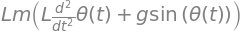


Solved for the equation of motion, theta_ddot =


Verified: matches the textbook pendulum equation theta'' = -(g/L)*sin(theta)
EXACTLY -- derived from L=T-V and the Euler-Lagrange equation, not assumed.

--> 1 DOF (theta) produced 1 Euler-Lagrange equation -- that correspondence
    (n DOF => n coupled 2nd-order ODEs) IS what 'degrees of freedom' means
    operationally, not just a count of numbers.


In [16]:
t = sp.symbols('t', real=True)
theta = sp.Function('theta')(t)   # the ONE generalized coordinate (1 DOF)
L_len, m, g = sp.symbols('L m g', positive=True)

# Cartesian position of the bob IN TERMS OF the single DOF theta --
# this is where "3 coordinates, 1 DOF" gets enforced: x,y both depend on
# theta alone, not on two independent coordinates.
x_bob = L_len * sp.sin(theta)
y_bob = -L_len * sp.cos(theta)

vx = sp.diff(x_bob, t)
vy = sp.diff(y_bob, t)
speed_sq = sp.simplify(vx**2 + vy**2)
print("bob speed^2 in terms of the single DOF theta(t):")
display(speed_sq)

T = sp.Rational(1, 2) * m * speed_sq
V = m * g * y_bob
Lagrangian = sp.simplify(T - V)
print("\nL = T - V =")
display(Lagrangian)

theta_dot = sp.diff(theta, t)
dL_dthetadot = sp.diff(Lagrangian, theta_dot)
d_dt_dL_dthetadot = sp.diff(dL_dthetadot, t)
dL_dtheta = sp.diff(Lagrangian, theta)

euler_lagrange = sp.simplify(d_dt_dL_dthetadot - dL_dtheta)
print("\nEuler-Lagrange: d/dt(dL/d theta_dot) - dL/d theta =")
display(euler_lagrange)

theta_ddot = sp.diff(theta, t, 2)
eom = sp.solve(sp.Eq(euler_lagrange, 0), theta_ddot)[0]
print("\nSolved for the equation of motion, theta_ddot =")
display(sp.simplify(eom))

expected = -g/L_len * sp.sin(theta)
assert sp.simplify(eom - expected) == 0
print("\nVerified: matches the textbook pendulum equation theta'' = -(g/L)*sin(theta)")
print("EXACTLY -- derived from L=T-V and the Euler-Lagrange equation, not assumed.")
print("\n--> 1 DOF (theta) produced 1 Euler-Lagrange equation -- that correspondence")
print("    (n DOF => n coupled 2nd-order ODEs) IS what 'degrees of freedom' means")
print("    operationally, not just a count of numbers.")

## Glossary (one line each)

| Symbol | Meaning |
|---|---|
| $\hat r$ | unit vector pointing radially outward |
| $\nabla f$ | gradient: vector of partial derivatives of $f$ |
| $\nabla\cdot \vec F$ | divergence: sum of matching partial derivatives |
| $\nabla\times \vec F$ | curl: antisymmetric combination of partial derivatives |
| $i$ | $\sqrt{-1}$, the imaginary unit |
| $\Psi^*$ | complex conjugate: flip the sign of every $i$ |
| $\lvert\Psi\rvert^2 = \Psi^*\Psi$ | probability density; always real even though $\Psi$ is complex |
| $\langle Q \rangle$ | expectation value: $\int \Psi^* Q\, \Psi\, dx$, the probability-weighted average of operator $Q$ |
| $\partial/\partial x$ | partial derivative (holding other variables fixed) |
| $d/dx$ | total/ordinary derivative (single-variable functions) |

## Summary

Real-space vector calculus ($\hat r$, $\nabla$, divergence, curl) was built
component by component via explicit loops over the coordinate axes;
imaginary-space QM notation ($i$, $\Psi^*$, $|\Psi|^2$, $\langle Q\rangle$)
was built by literally splitting a concrete complex test function into its
real and imaginary parts and checking every claimed identity numerically
(conjugation matches `sp.conjugate`, $|\Psi|^2$ is exactly real, the
reconstruction $\text{Re}+i\,\text{Im}=\Psi$ holds exactly) rather than
asserting any of it.

| $\vec r\,'$ | source point: where the charge/current sits |
| $\mathscr{r}=\vec r-\vec r\,'$ | separation vector: source to field point |
| equipotential | surface where $V=$const; spheres around a point source |
| DOF | number of independent generalized coordinates $q_i$ |
| $L=T-V$ | Lagrangian; Euler-Lagrange gives 1 ODE per DOF |
| $\delta^3(\vec r)$ | 3D Dirac delta: zero except at origin, integrates to 1 |
| $\nabla\cdot(\hat{\mathscr{r}}/\mathscr{r}^2)=4\pi\delta^3(\mathscr{r})$ | Gauss's law works AT a point charge |
| Helmholtz theorem | $\vec F=-\nabla\phi+\nabla\times\vec A$ for any smooth field |
| $\nabla\times(\nabla\times\vec A)$ | $=\nabla(\nabla\cdot\vec A)-\nabla^2\vec A$ (verified symbolically above) |